In [6]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import TruncatedExponentialFamilyDistributionNLL, calc_poiss_suff_stat, ExponentialFamilyPoisson

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from torch.distributions import Poisson

In [4]:
def trunc_nll(phi, theta, data, D, calc_suff_stat):
    theta.requires_grad = True
    loss = TruncatedExponentialFamilyDistributionNLL.apply(
        theta, data, phi, dims, D, calc_suff_stat, 10000
    )
    loss.backward()
    return loss.item(), theta.grad

# 1 Dimensional Exponential Distribution

In [11]:
# === Ground truth parameters ===
dims = 1
lambda_ = ch.Tensor([5.0])
print(f'true lambda_: {lambda_}')

true lambda_: tensor([5.])


alpha: 0.7334
Observed lambda: [5.970139026641846]


<IPython.core.display.Javascript object>


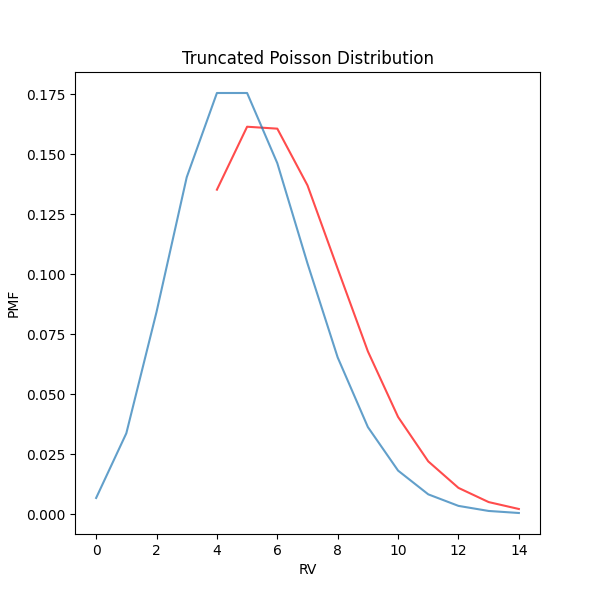

In [25]:
# === Synthetic truncated dataset ===
dist = Poisson(lambda_)
NUM_SAMPLES = 10000
samples = dist.sample((NUM_SAMPLES,))

def phi(z):
    return z > 3.0

S = samples[phi(samples)]

alpha = S.size(0) / NUM_SAMPLES
print(f'alpha: {alpha}')

emp_lambda_ = S.mean(0, keepdim=True) # empirical mean as observed sample
print(f"Observed lambda: {emp_lambda_.tolist()}")
truncated_dist = Poisson(emp_lambda_)

unique_S = S.unique()
unique_samples = samples.unique()
S_pdf = ch.exp(truncated_dist.log_prob(unique_S)).detach()
samples_pdf = ch.exp(dist.log_prob(unique_samples)).detach()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.plot(unique_S, S_pdf, alpha=0.7, color='red', label="Ground Truth Possion Distribution")

ax.plot(unique_samples, samples_pdf, alpha=0.7, label="Truncated Possion Distribution")
ax.set_xlabel("RV")
ax.set_ylabel("PMF")
ax.set_title('Truncated Poisson Distribution')
plt.show()

In [27]:
lambdas_ = ch.linspace(2.0, 10.0, 25)
data = ch.cat([S[...,None], calc_poiss_suff_stat(S[...,None])], dim=1)

losses = [trunc_nll(phi, ch.log(lambda_), data, ExponentialFamilyPoisson, calc_poiss_suff_stat)[0] for lambda_ in lambdas_]

<IPython.core.display.Javascript object>


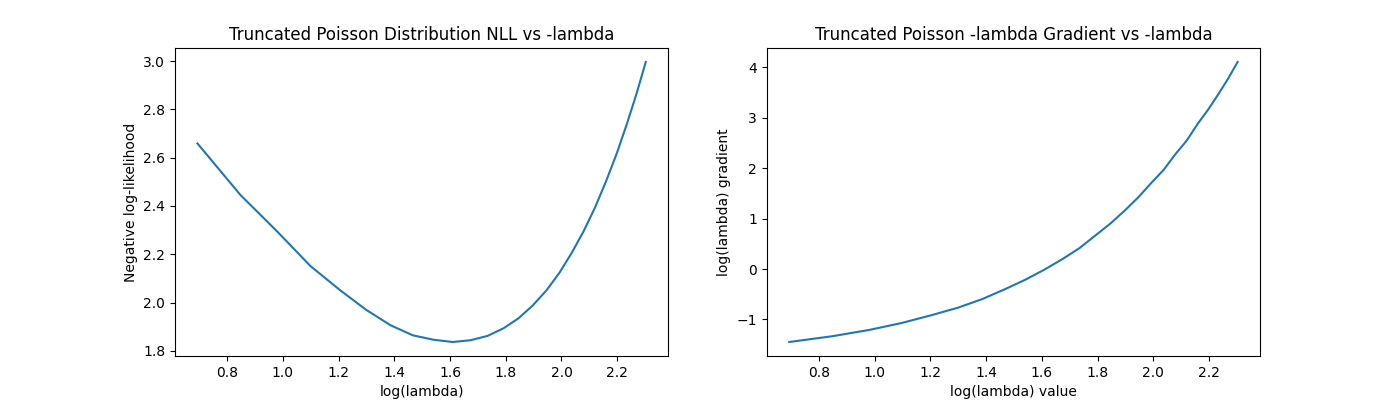

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(ch.log(lambdas_), losses)
ax1.set_xlabel("log(lambda)")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Poisson Distribution NLL vs -lambda")
    
lambda_grads = [trunc_nll(phi, ch.log(lambda_), data, ExponentialFamilyPoisson, calc_poiss_suff_stat)[1].item() for lambda_ in lambdas_]

ax2.plot(ch.log(lambdas_), lambda_grads)
ax2.set_xlabel("log(lambda) value")
ax2.set_ylabel("log(lambda) gradient")
ax2.set_title("Truncated Poisson -lambda Gradient vs -lambda")


plt.show()

# 2 Dimensional Truncated Exponential Distribution

In [33]:
dims = 2 
lambda_ = ch.Tensor([1.0, 2.0])

dist = Poisson(lambda_)
NUM_SAMPLES = 10000
samples = dist.sample((NUM_SAMPLES,))

def phi(z):
    return z[:,0] > .5

S = samples[phi(samples)]

alpha = S.size(0) / NUM_SAMPLES
print(f'alpha: {alpha}')

alpha: 0.6284


In [34]:
# ch.manual_seed(0)
# === Parameter grids ===
lambda1_values = ch.linspace(.5, 4.0, 25)
lambda2_values = ch.linspace(.5, 4.0, 25)
LAMBDA1_, LAMBDA2_ = ch.meshgrid(lambda1_values, lambda2_values)

# DATA 
S_suff_stat = calc_poiss_suff_stat(S)
data = ch.cat([S, S_suff_stat], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(LAMBDA1_)
GRAD_LAMBDA1 = np.zeros_like(LAMBDA1_)
GRAD_LAMBDA2 = np.zeros_like(LAMBDA2_)
for i in range(len(lambda1_values)):
    for j in range(len(lambda2_values)):
        lambda_temp = ch.Tensor([LAMBDA1_[i, j], LAMBDA2_[i, j]])
        theta = ch.log(lambda_temp)
        loss, theta_grad = trunc_nll(phi, theta, data, ExponentialFamilyPoisson, calc_poiss_suff_stat)
        Z[i, j] = loss
        GRAD_LAMBDA1[i, j] = theta_grad[0]
        GRAD_LAMBDA2[i, j] = theta_grad[1]

/home/patroklos/base/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Ground truth: log(lambda)=tensor([0.0000, 0.6931])
Minimum found: log(lambda1_min)=nan, log(lambda2_min)=-0.296, loss=2.722

Loss at ground truth: 2.720
Loss at minimum: 2.722
Difference: -0.002


<IPython.core.display.Javascript object>


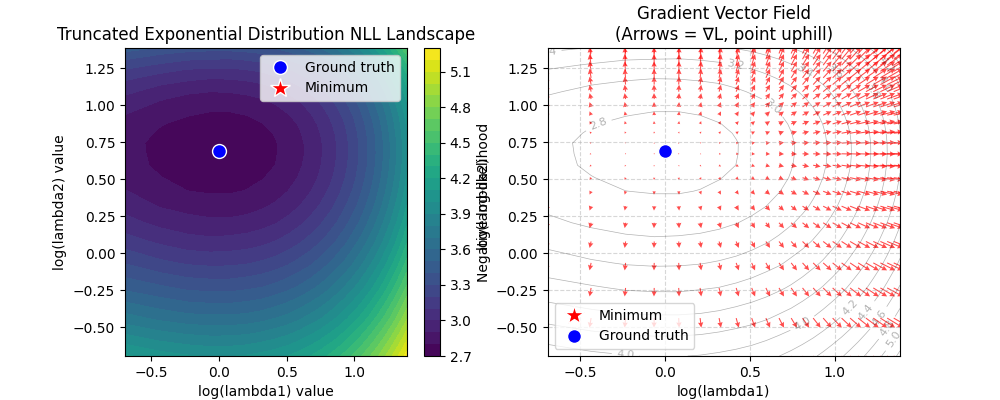

In [35]:
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
LAMBDA1_min, LAMBDA2_min = ch.log(LAMBDA1_[min_idx]), ch.log(LAMBDA2_[min_idx])
min_loss = Z[min_idx]

print(f"Ground truth: log(lambda)={ch.log(lambda_)}")
print(f"Minimum found: log(lambda1_min)={ch.log(LAMBDA1_min).item():.3f}, log(lambda2_min)={ch.log(LAMBDA2_min).item():.3f}, loss={min_loss:.3f}")
gt_loss, gt_grad = trunc_nll(phi, ch.log(lambda_), data, ExponentialFamilyPoisson, calc_poiss_suff_stat)
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

cp = ax1.contourf(ch.log(LAMBDA1_), ch.log(LAMBDA2_), Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Exponential Distribution NLL Landscape")
ax1.set_xlabel("log(lambda1) value")
ax1.set_ylabel("log(lambda2) value")

# mark the ground truth
ax1.plot(ch.log(lambda_[0]).item(), ch.log(lambda_[1]).item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax1.plot(ch.log(LAMBDA1_min).item(), ch.log(LAMBDA2_min).item(), 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax1.legend()

# Plot quiver
Q = ax2.quiver(ch.log(LAMBDA1_), ch.log(LAMBDA2_), GRAD_LAMBDA1, GRAD_LAMBDA2,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax2.contour(ch.log(LAMBDA1_), ch.log(LAMBDA2_), Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax2.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax2.plot(ch.log(LAMBDA1_min), ch.log(LAMBDA2_min), 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax2.plot(ch.log(lambda_[0]).item(), ch.log(lambda_)[1].item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax2.set_xlabel('log(lambda1)')
ax2.set_ylabel('log(lambda2)')
ax2.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)


plt.show()

<IPython.core.display.Javascript object>


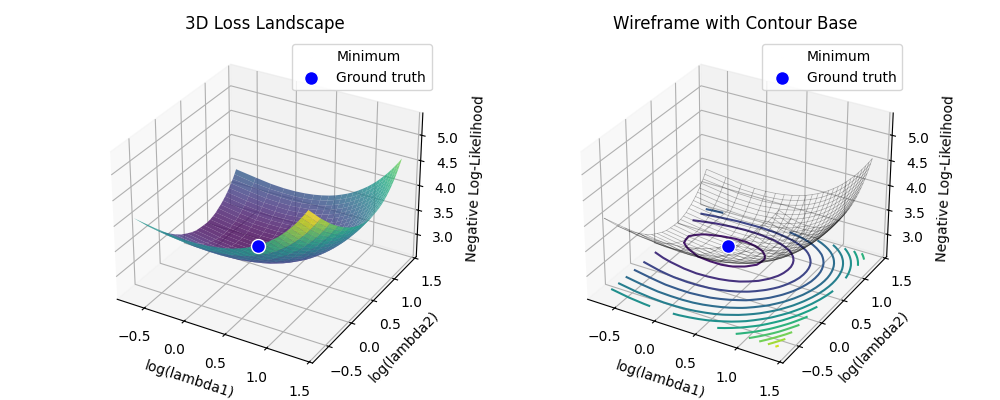

In [36]:
# === Create 3D visualization ===
fig = plt.figure(figsize=(10, 4))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(ch.log(LAMBDA1_), ch.log(LAMBDA2_), Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax1.scatter([ch.log(LAMBDA1_min)], [ch.log(LAMBDA2_min)], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax1.scatter([ch.log(lambda_[0]).item()], [ch.log(lambda_[1]).item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax1.set_xlabel('log(lambda1)')
ax1.set_ylabel('log(lambda2)')
ax1.set_zlabel('Negative Log-Likelihood')
ax1.set_title('3D Loss Landscape')
ax1.legend()

# Plot 2: 3D wireframe plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_wireframe(ch.log(LAMBDA1_), ch.log(LAMBDA2_), Z, color='black', alpha=0.3, linewidth=0.5)
contour = ax2.contour(ch.log(LAMBDA1_), ch.log(LAMBDA2_), Z, levels=15, offset=np.min(Z) - 0.1, cmap='viridis')
ax2.scatter([ch.log(LAMBDA1_min)], [ch.log(LAMBDA2_min)], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax2.scatter([ch.log(lambda_[0]).item()], [ch.log(lambda_[1]).item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax2.set_xlabel('log(lambda1)')
ax2.set_ylabel('log(lambda2)')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('Wireframe with Contour Base')
ax2.legend()

plt.tight_layout()
plt.show()

# 10 Dimensional Gaussians

In [116]:
dims = 10
true_mu = ch.randn(dims) 
true_Sigma = 10.0 * ch.eye(dims)
dist = MultivariateNormal(true_mu, true_Sigma)

print(f'true mu: {true_mu.tolist()}')
print(f'true Sigma: {true_Sigma.tolist()}')

true mu: [0.6417242288589478, 1.2395769357681274, -0.6739909052848816, -0.40306341648101807, -0.5634419322013855, -0.25038883090019226, -0.20058777928352356, -0.9689702987670898, -0.8504588007926941, 0.8115679621696472]
true Sigma: [[10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0]]


# Random Matrix Projection

Observed mean (x): [[0.6426495313644409, 1.214259147644043, -0.6448889970779419, -0.4279410243034363, -0.5095582008361816, -0.2100946605205536, -0.22225482761859894, -0.8954321146011353, -0.8628897666931152, 0.8183324933052063]]
Total samples: 10000
Truncated samples: 9972
Acceptance rate: 0.9972
Min 10D norm in truncated set: 4.506
Max 10D norm: 19.208
Effective 2D radius (min): 0.17


<IPython.core.display.Javascript object>


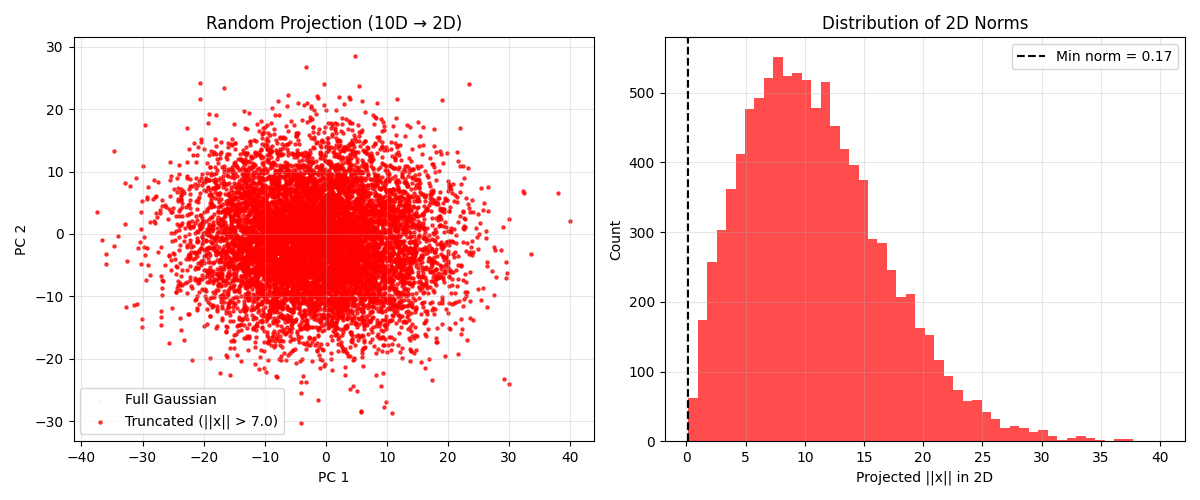

In [117]:
dist = MultivariateNormal(true_mu, true_Sigma)
samples = dist.sample([10000])
# === Truncation region ===
def phi(z):
    # Keep only samples, where norm of the sample is larger than 4.5
    return samples.norm(dim=1, keepdim=True) > 4.5
mask = phi(samples)
S = samples[mask.nonzero()[:,0]]
S_grad = calc_multivariate_normal_sufficient_statistic(S)
data = ch.cat([S, S_grad], dim=1)
acceptance_rate = S.size(0) / samples.size(0)
x_obs = samples.mean(0, keepdim=True) # empirical mean as observed sample

print(f"Observed mean (x): {x_obs.tolist()}")
print(f"Total samples: {samples.shape[0]}")
print(f"Truncated samples: {S.shape[0]}")
print(f"Acceptance rate: {S.shape[0] / samples.shape[0]:.4f}")
print(f"Min 10D norm in truncated set: {S.norm(dim=1).min().item():.3f}")
print(f"Max 10D norm: {S.norm(dim=1).max().item():.3f}")

# Project with a random matrix
W = ch.randn(10, 2)
S_2d = S @ W
samples_full_2d = samples @ W

projected_norms = np.linalg.norm(S_2d, axis=1)
R_eff = projected_norms.min()  # or use percentile
print(f"Effective 2D radius (min): {R_eff:.2f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Full vs truncated in 2D PCA space
ax1.scatter(samples_full_2d[:, 0], samples_full_2d[:, 1], 
           s=1, alpha=0.3, label='Full Gaussian', color='lightgray')
ax1.scatter(S_2d[:, 0], S_2d[:, 1], 
           s=5, alpha=0.7, label='Truncated (||x|| > 7.0)', color='red')
ax1.set_title('Random Projection (10D → 2D)')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of projected norms
ax2.hist(projected_norms, bins=50, color='red', alpha=0.7)
ax2.axvline(R_eff, color='black', linestyle='--', label=f'Min norm = {R_eff:.2f}')
ax2.set_xlabel('Projected ||x|| in 2D')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of 2D Norms')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Marginzalized Projection 

In [9]:
x_marg = S[:, :2].cpu()
norms_10d = S.norm(dim=1).cpu()

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
fig1 = ax1.scatter(x_marg[:, 0], x_marg[:, 1], c=norms_10d, s=5, alpha=0.7)
plt.colorbar(fig1, ax=ax1, label='10D Norm (all > 7.0)')
ax1.set_title('2D Marginal Colored by 10D Norm')
plt.show()

NameError: name 'S' is not defined

In [4]:
from delphi import oracle

dims = 1

true_mu, true_var = ch.zeros(dims), ch.eye(dims)
true_T = true_var.inverse()
true_v = true_mu@true_T
M = MultivariateNormal(true_mu, true_var) 
print(f'ground truth loc: {true_mu}')
print(f'ground truth var: {true_var}')
samples = M.rsample([5000,])

print(f'num total samples: {samples.size(0)}')
# generate ground-truth data
phi = oracle.Left_Distribution(ch.Tensor([0.0]))
# truncate
indices = phi(samples).nonzero()[:,0]
S = samples[indices]
print(f'num truncated samples: {S.size(0)}')
alpha = S.size(0) / samples.size(0)
emp_loc = S.mean(0)
emp_var = S.var(0)
print(f"emp loc: {emp_loc}")
print(f'emp var: {emp_var}')

ground truth loc: tensor([0.])
ground truth var: tensor([[1.]])
num total samples: 5000
num truncated samples: 2517
emp loc: tensor([0.8209])
emp var: tensor([0.3700])


In [5]:
from delphi.distributions import TruncatedNormal
from delphi.utils.helpers import Parameters

S_std_norm = (S - emp_loc) 
phi_std_norm = oracle.Left_Distribution((phi.left - emp_loc).flatten())

# train algorithm
args = Parameters({
                    'iterations': 1500, 
                    'batch_size': 1, 
                    'trials': 1, 
                    'verbose': True,
                    'lr': 1e-1,
                    'num_samples': 1000,
                    'optimizer': 'sgd',
#                     'momentum': .9
                }) 
truncated = TruncatedNormal(args,
                              phi_std_norm, 
                              alpha, 
                              dims,
                              variance=ch.eye(1))
truncated.fit(S_std_norm)

rescale_loc = truncated.best_loc_ + emp_loc
print(f"pred loc: {rescale_loc}")
rescale_var = truncated.best_variance_
print(f"pred var: {rescale_var}")

[2025-12-08 16:45:15] INFO - trial: 1, training: TruncatedNormal() with the following config:
 {'batch_size': 1,
 'dampening': 0.0,
 'device': 'cpu',
 'differentiable': False,
 'disable_no_grad': False,
 'drop_last': False,
 'early_stopping': False,
 'ema_decay': 0.99,
 'eps': 1e-05,
 'grad_tol': 0,
 'iterations': 1500,
 'log_every': 50,
 'lr': 0.1,
 'maximize': False,
 'momentum': 0.0,
 'nesterov': False,
 'normalize': False,
 'num_samples': 1000,
 'optimizer': 'sgd',
 'patience': inf,
 'pin_memory': True,
 'r': 1.0,
 'rate': 1.5,
 'shuffle': True,
 'tol': 0.1,
 'trials': 1,
 'val': 0.2,
 'verbose': True,
 'weight_decay': 0.0,
 'workers': 0}
[2025-12-08 16:45:15] INFO - [train] epoch=1 step=50 loss=0.8003 grad_norm=3.847e-01
[2025-12-08 16:45:15] INFO - [train] epoch=1 step=100 loss=0.9328 grad_norm=5.882e-01
[2025-12-08 16:45:15] INFO - [train] epoch=1 step=150 loss=0.8989 grad_norm=3.867e-01
[2025-12-08 16:45:15] INFO - [train] epoch=1 step=200 loss=0.8456 grad_norm=1.601e-01
[2025-

pred loc: tensor([-0.4038])
pred var: tensor([[1.]])


In [6]:
truncated.ema_loc_ + emp_loc

tensor([0.0532])

In [7]:
dims = 1
sampler = PreSampler(dims, 10000000)
S_grad = calc_multivariate_normal_sufficient_statistic(S)
data = ch.cat([S, S_grad], dim=1)

mus = ch.linspace(-1, 2, 10)
losses = [trunc_nll(phi, ch.tensor([m]), ch.eye(1), data, sampler=sampler)[0] for m in mus]

<IPython.core.display.Javascript object>


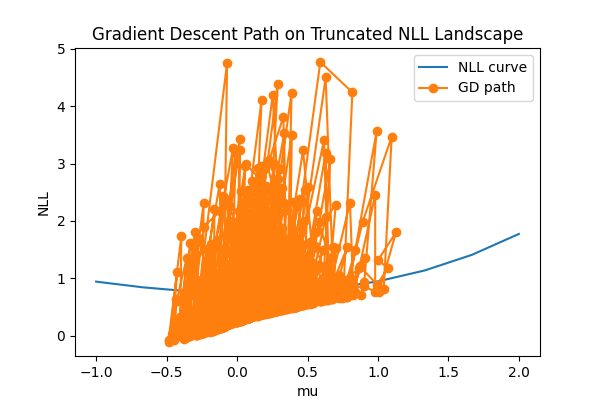

In [8]:
mu_history = truncated.trainer.param_history.detach() + emp_loc
loss_history = truncated.trainer.train_losses.detach()

plt.figure(figsize=(6,4))
plt.plot(mus, losses, label="NLL curve")
plt.plot(mu_history, loss_history, marker="o", label="GD path")
plt.xlabel("mu")
plt.ylabel("NLL")
plt.title("Gradient Descent Path on Truncated NLL Landscape")
plt.legend()
plt.show()

In [9]:
(truncated.trainer.param_history + emp_loc).mean(0)

tensor([0.1671])

In [22]:
S_std_norm = (S - emp_loc) / (emp_var ** .5)
phi_std_norm = oracle.Left_Distribution((phi.left - emp_loc).flatten() / (emp_var ** .5))

# train algorithm
args = Parameters({
                    'epochs': 3, 
                    'batch_size': 1, 
                    'trials': 1, 
                    'verbose': True,
                    'lr': 1e-2,
                    'num_samples': 1000,
                    'optimizer': 'sgd',
#                     'momentum': .25,
                    'step_lr': 1500, 
                    'step_lr_gamma': .95,
                    'covariance_matrix_lr': 1e-2
                }) 
truncated = TruncatedNormal(args,
                              phi_std_norm, 
                              alpha, 
                              dims)
truncated.fit(S_std_norm)

[2025-12-08 16:47:45] INFO - trial: 1, training: TruncatedNormal() with the following config:
 {'batch_size': 1,
 'covariance_matrix_lr': 0.01,
 'dampening': 0.0,
 'device': 'cpu',
 'differentiable': False,
 'disable_no_grad': False,
 'drop_last': False,
 'early_stopping': False,
 'ema_decay': 0.99,
 'epochs': 3,
 'eps': 1e-05,
 'grad_tol': 0,
 'log_every': 50,
 'lr': 0.01,
 'maximize': False,
 'momentum': 0.0,
 'nesterov': False,
 'normalize': False,
 'num_samples': 1000,
 'optimizer': 'sgd',
 'patience': inf,
 'pin_memory': True,
 'r': 1.0,
 'rate': 1.5,
 'shuffle': True,
 'step_lr': 1500,
 'step_lr_gamma': 0.95,
 'tol': 0.1,
 'trials': 1,
 'val': 0.2,
 'verbose': True,
 'weight_decay': 0.0,
 'workers': 0}
[2025-12-08 16:47:45] INFO - [train] epoch=1 step=50 loss=1.2558 grad_norm=9.305e-01
[2025-12-08 16:47:45] INFO - [train] epoch=1 step=100 loss=1.1977 grad_norm=1.256e+00
[2025-12-08 16:47:45] INFO - [train] epoch=1 step=150 loss=1.2026 grad_norm=1.161e+00
[2025-12-08 16:47:45] INF

[2025-12-08 16:47:48] INFO - [train] epoch=3 step=4300 loss=1.2122 grad_norm=4.713e-01
[2025-12-08 16:47:48] INFO - [train] epoch=3 step=4350 loss=1.2092 grad_norm=4.456e-01
[2025-12-08 16:47:48] INFO - [train] epoch=3 step=4400 loss=1.2251 grad_norm=5.829e-01
[2025-12-08 16:47:48] INFO - [train] epoch=3 step=4450 loss=1.2359 grad_norm=5.931e-01
[2025-12-08 16:47:48] INFO - [train] epoch=3 step=4500 loss=1.2415 grad_norm=6.361e-01
[2025-12-08 16:47:48] INFO - [train] epoch=3 step=4550 loss=1.2464 grad_norm=5.488e-01
[2025-12-08 16:47:48] INFO - [train] epoch=3 step=4600 loss=1.2527 grad_norm=6.302e-01
[2025-12-08 16:47:49] INFO - [train] epoch=3 step=4650 loss=1.2618 grad_norm=1.189e+00
[2025-12-08 16:47:49] INFO - [train] epoch=3 step=4700 loss=1.2689 grad_norm=8.966e-01
[2025-12-08 16:47:49] INFO - [train] epoch=3 step=4750 loss=1.2658 grad_norm=1.922e+00
[2025-12-08 16:47:49] INFO - [train] epoch=3 step=4800 loss=1.2596 grad_norm=4.185e+00
[2025-12-08 16:47:49] INFO - [train] epoch=

TruncatedNormal()

In [23]:
rescale_loc = truncated.best_loc_ * (emp_var ** .5) + emp_loc
print(f"pred loc: {rescale_loc}")
rescale_var = truncated.best_variance_ * emp_var
print(f"pred var: {rescale_var}")

ema_loc = truncated.ema_loc_ * (emp_var ** .5) + emp_loc
print(f"ema loc: {ema_loc}")
ema_var = truncated.ema_covariance_matrix_ * emp_var
print(f"ema var: {ema_var}")

avg_loc = truncated.avg_loc_ * (emp_var ** .5) + emp_loc
print(f"avg loc: {avg_loc}")
avg_var = truncated.avg_covariance_matrix_ * emp_var
print(f"avg var: {avg_var}")

pred loc: tensor([0.0634])
pred var: tensor([[0.7950]])
ema loc: tensor([0.0264])
ema var: tensor([[0.8779]])
avg loc: tensor([0.1238])
avg var: tensor([[0.8263]])


In [102]:
# ch.manual_seed(0)
# === Parameter grids ===
v_values = ch.linspace(-1.0, 3.0, 40)
T_values = ch.linspace(0.5, 3.0, 40)
V_, T_ = ch.meshgrid(v_values, T_values)

# DATA 
sampler = PreSampler(dims)
S_grad = calc_multivariate_normal_sufficient_statistic(S)
data = ch.cat([S, S_grad], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(V_)
GRAD_V = np.zeros_like(V_)
GRAD_T = np.zeros_like(T_)
for i in range(len(v_values)):
    for j in range(len(T_values)):
        T = ch.Tensor([[T_[i, j]]])
        v = V_[i, j][...,None]
        loss, T_grad, v_grad = trunc_nll(phi, v, T, data, known_cov=False, sampler=None)
        Z[i, j] = loss
        GRAD_V[i, j] = v_grad
        GRAD_T[i, j] = T_grad

RuntimeError: shape '[100, 100]' is invalid for input of size 1

Ground truth: v=0.000, T=1.000
Minimum found: v=-0.179, T=0.821, loss=0.735

Loss at ground truth: 0.739
Loss at minimum: 0.735
Difference: 0.004


<IPython.core.display.Javascript object>


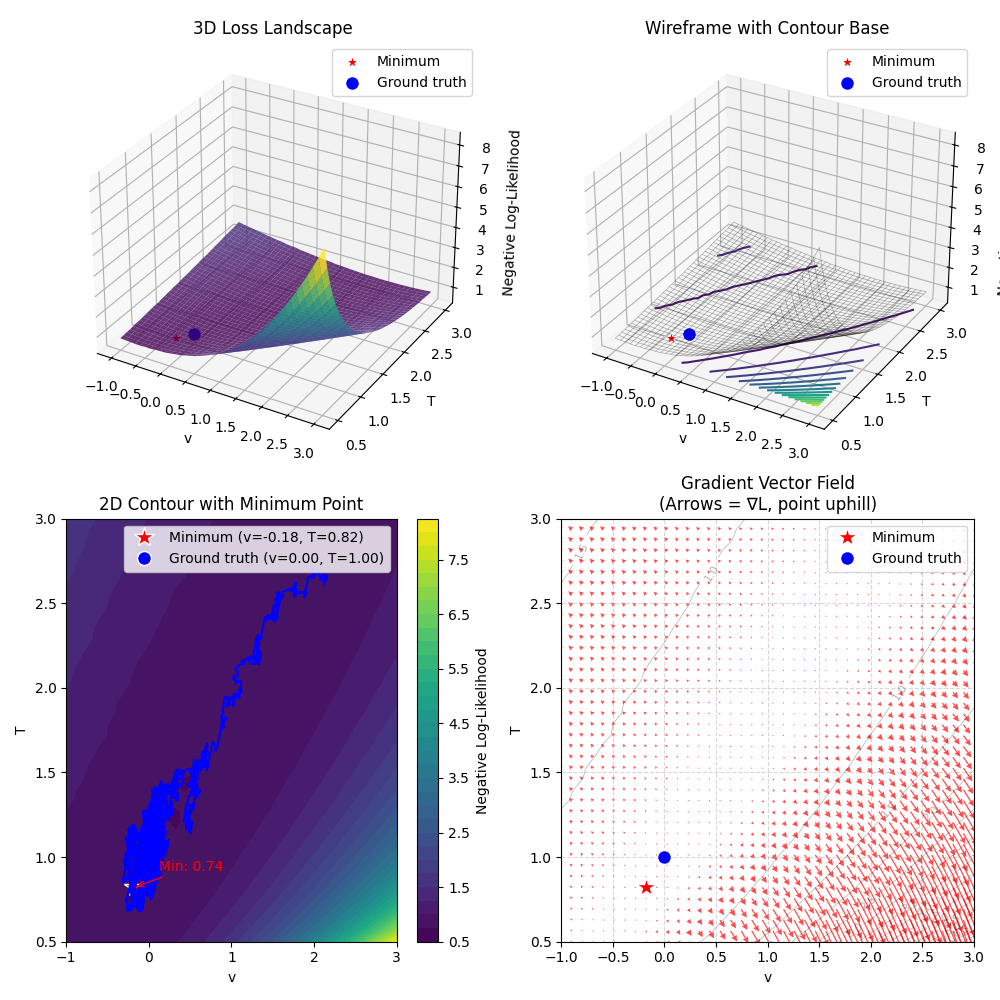

In [25]:
# Find the minimum point
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_v = V_[min_idx]
min_T = T_[min_idx]
min_loss = Z[min_idx]

# === Analysis ===
print(f"Ground truth: v={true_mu.item():.3f}, T={true_var.item():.3f}")
print(f"Minimum found: v={min_v:.3f}, T={min_T:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_nll(phi, true_mu, true_var, data)[0]
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

param_history = truncated.trainer.param_history 

T = param_history[:,0]
v = param_history[:,1]

SIGMA_ = 1/T
MU_ = SIGMA_*v

ORIG_SIGMA_ = SIGMA_ * emp_var
ORIG_MU_ = MU_ * (emp_var**.5) + emp_loc

T_history = 1/ORIG_SIGMA_
v_history = ORIG_MU_*T_history

# === Create 3D visualization ===
fig = plt.figure(figsize=(10, 10))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(221, projection='3d')
surf = ax1.plot_surface(V_, T_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax1.scatter([min_v], [min_T], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax1.scatter([true_v.item()], [true_T.item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax1.set_xlabel('v')
ax1.set_ylabel('T')
ax1.set_zlabel('Negative Log-Likelihood')
ax1.set_title('3D Loss Landscape')
ax1.legend()

# Plot 2: 3D wireframe plot
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot_wireframe(V_, T_, Z, color='black', alpha=0.3, linewidth=0.5)
contour = ax2.contour(V_, T_, Z, levels=15, offset=np.min(Z) - 0.1, cmap='viridis')
ax2.scatter([min_v], [min_T], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_v.item()], [true_T.item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax2.set_xlabel('v')
ax2.set_ylabel('T')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('Wireframe with Contour Base')
ax2.legend()

# Plot 3: Heatmap with minimum point
ax3 = fig.add_subplot(223)
contourf = ax3.contourf(V_, T_, Z, levels=30, cmap='viridis')
plt.colorbar(contourf, ax=ax3, label='Negative Log-Likelihood')

# Mark minimum and ground truth
ax3.plot(min_v, min_T, 'r*', markersize=15, markeredgecolor='white', 
        label=f'Minimum (v={min_v.item():.2f}, T={min_T.item():.2f})')
ax3.plot(true_v.item(), true_T.item(), 'bo', markersize=10, 
        markeredgecolor='white', label=f'Ground truth (v={true_v.item():.2f}, T={true_T.item():.2f})')

# Add text annotation for the minimum point
ax3.annotate(f'Min: {min_loss:.2f}', 
            xy=(min_v, min_T), 
            xytext=(min_v+0.3, min_T+0.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax3.plot(v_history.detach(), T_history.detach(), color='blue')


ax3.set_xlabel('v')
ax3.set_ylabel('T')
ax3.set_title('2D Contour with Minimum Point')
ax3.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(224)

# Plot quiver
Q = ax4.quiver(V_, T_, GRAD_V, GRAD_T,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(V_, T_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(min_v, min_T, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax4.plot(true_v.item(), true_T.item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax4.set_xlabel('v')
ax4.set_ylabel('T')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [26]:
val_dataset = truncated.val_loader_.dataset.S
val_grad = trunc_multi_norm_score(val_dataset)
val_data = ch.cat([val_dataset, val_grad], dim=1)

In [103]:
val_losses = []

for i in range(param_history.size(0) - 500): 
    with ch.no_grad():
        params = param_history[500+i].detach()
    
    T, v = params[0].reshape(1, 1), params[1].reshape(1,)
    T.requires_grad = True
    v.requires_grad = True
    loss, T_grad, v_grad = trunc_nll(phi_std_norm, v, T, val_data, known_cov=False, sampler=None)

    val_losses.append(ch.Tensor([loss]))
    
    

RuntimeError: shape '[100, 100]' is invalid for input of size 1

In [28]:
print(T_history[500 + ch.stack(val_losses).argmin()])
print(v_history[500 + ch.stack(val_losses).argmin()])

tensor(1.0127)
tensor(-0.0307)


In [56]:
from delphi import oracle
from delphi.utils.helpers import cov

dims = 100
NUM_SAMPLES = 10000

true_mu, true_var = ch.zeros(dims), ch.eye(dims)
true_T = true_var.inverse()
true_v = true_mu@true_T
M = MultivariateNormal(true_mu, true_var) 
print(f'ground truth loc: {true_mu}')
print(f'ground truth var: {true_var}')
samples = M.rsample([NUM_SAMPLES,])
print(f'num total samples: {samples.size(0)}')
# generate ground-truth data
phi = oracle.Left_Distribution(ch.Tensor([0.0] + [-ch.inf]*(dims-1)))
# truncate
indices = phi(samples).nonzero()[:,0]
S = samples[indices]
alpha = S.size(0) / NUM_SAMPLES
print(f'alpha: {alpha}')
print(f'num truncated samples: {S.size(0)}')
alpha = S.size(0) / samples.size(0)
emp_loc = S.mean(0)
emp_cov = cov(S)
emp_var = S.var(0, keepdim=True)
print(f"emp loc: {emp_loc}")
print(f'emp cov:\n {emp_cov}')

S_std_norm = S - emp_loc

ground truth loc: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.])
ground truth var: tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
num total samples: 10000
alpha: 0.5124
num truncated samples: 5124
emp loc: tensor([ 8.0038e-01, -8.2761e-03, -6.6502e-04, -3.7900e-03, -2.5372e-02,
         7.3608e-03,  1.3714e-03,  3.2371e-02,  2.7715e-02, -6.8232e-03,
         1.6636e-04,  1.4001e-02,  2.4328e-02, 

In [57]:
from delphi.distributions import TruncatedMultivariateNormal
from delphi.utils.helpers import Parameters
from delphi.grad import Sampler

phi_std_norm = oracle.Left_Distribution((phi.left - emp_loc).flatten())

# train algorithm
args = Parameters({
                    'epochs': 1, 
                    'batch_size': 1, 
                    'trials': 1, 
                    'verbose': True,
                    'lr': 1e-2,
                    'num_samples': 1000,
                    'optimizer': 'sgd', 
#                     'nesterov': True,
#                     'momentum': .5
                }) 
truncated = TruncatedMultivariateNormal(args,
                                          phi_std_norm, 
                                          alpha, 
                                          dims,
                                          covariance_matrix=ch.eye(dims), 
                                           sampler=Sampler())
truncated.fit(S_std_norm)

[2025-12-09 16:35:42] INFO - trial: 1, training: TruncatedMultivariateNormal() with the following config:
 {'batch_size': 1,
 'dampening': 0.0,
 'device': 'cpu',
 'differentiable': False,
 'disable_no_grad': False,
 'drop_last': False,
 'early_stopping': False,
 'ema_decay': 0.99,
 'epochs': 1,
 'eps': 1e-05,
 'grad_tol': 0,
 'log_every': 50,
 'lr': 0.01,
 'maximize': False,
 'momentum': 0.0,
 'nesterov': False,
 'normalize': False,
 'num_samples': 1000,
 'optimizer': 'sgd',
 'patience': inf,
 'pin_memory': True,
 'r': 1.0,
 'rate': 1.5,
 'shuffle': True,
 'tol': 0.1,
 'trials': 1,
 'val': 0.2,
 'verbose': True,
 'weight_decay': 0.0,
 'workers': 0}
[2025-12-09 16:35:48] INFO - [train] epoch=1 step=50 loss=144.4956 grad_norm=1.153e+01
[2025-12-09 16:35:55] INFO - [train] epoch=1 step=100 loss=142.7801 grad_norm=9.717e+00
[2025-12-09 16:36:01] INFO - [train] epoch=1 step=150 loss=142.3710 grad_norm=8.548e+00
[2025-12-09 16:36:07] INFO - [train] epoch=1 step=200 loss=141.8706 grad_norm=9.

TruncatedMultivariateNormal()

In [58]:
best_loc = truncated.best_loc_ + emp_loc
print(f"best loc: {best_loc}")

ema_loc = truncated.ema_loc_ + emp_loc
print(f"ema loc: {ema_loc}")

avg_loc = truncated.avg_loc_ + emp_loc
print(f"avg loc: {avg_loc}")

best loc: tensor([ 0.0706, -0.0708, -0.0677, -0.0576,  0.0349,  0.0897,  0.0139,  0.0553,
         0.0845,  0.0671, -0.1244, -0.0435,  0.0427,  0.1181,  0.0145, -0.0173,
        -0.0163, -0.1242,  0.0859,  0.0574,  0.0879, -0.0235, -0.0945,  0.0092,
        -0.0043, -0.0162, -0.0953,  0.0712, -0.1020,  0.0373, -0.0431,  0.0483,
         0.0794, -0.0484,  0.1350, -0.0219, -0.0125,  0.1037, -0.1169, -0.0850,
         0.1137, -0.0622,  0.0534,  0.1067,  0.0386,  0.0905,  0.0506, -0.0218,
         0.0406, -0.0801, -0.0417, -0.0338, -0.0961, -0.0757,  0.1713,  0.0187,
        -0.0097,  0.1569, -0.0238, -0.0476, -0.0070,  0.0523, -0.0194, -0.0615,
        -0.1061, -0.0060, -0.0691, -0.0166,  0.0083,  0.0182,  0.0205,  0.0359,
        -0.0209,  0.1124,  0.0018, -0.0888, -0.0998, -0.0376,  0.0118,  0.0182,
        -0.0770,  0.0129,  0.0157,  0.1904,  0.1348,  0.0018, -0.0169, -0.1986,
         0.1274,  0.0769, -0.1541,  0.1261, -0.1202,  0.0206,  0.1189,  0.0593,
         0.1473, -0.0271, -0.1

In [62]:
from delphi.distributions import TruncatedMultivariateNormal
from delphi.utils.helpers import Parameters

S_std_norm = (S - emp_loc)/ch.sqrt(emp_var) 
phi_std_norm = oracle.Left_Distribution(((phi.left - emp_loc)/ch.sqrt(emp_var)).flatten())

# train algorithm
args = Parameters({
                    'iterations': 5000, 
                    'batch_size': 1, 
                    'trials': 1, 
                    'verbose': True,
                    'lr': 1e-2,
                    'num_samples': 1000,
                    'optimizer': 'sgd',
                    'val_interval': 100,
#                     'covariance_matrix_lr': 1e-2,
                    'val': .2
                }) 
truncated = TruncatedMultivariateNormal(args,
                                          phi_std_norm, 
                                          alpha, 
                                          dims, 
                                        sampler=Sampler())
truncated.fit(S_std_norm)

[2025-12-09 16:54:42] INFO - trial: 1, training: TruncatedMultivariateNormal() with the following config:
 {'batch_size': 1,
 'dampening': 0.0,
 'device': 'cpu',
 'differentiable': False,
 'disable_no_grad': False,
 'drop_last': False,
 'early_stopping': False,
 'ema_decay': 0.99,
 'eps': 1e-05,
 'grad_tol': 0,
 'iterations': 5000,
 'log_every': 50,
 'lr': 0.01,
 'maximize': False,
 'momentum': 0.0,
 'nesterov': False,
 'normalize': False,
 'num_samples': 1000,
 'optimizer': 'sgd',
 'patience': inf,
 'pin_memory': True,
 'r': 1.0,
 'rate': 1.5,
 'shuffle': True,
 'tol': 0.1,
 'trials': 1,
 'val': 0.2,
 'val_interval': 100,
 'verbose': True,
 'weight_decay': 0.0,
 'workers': 0}
[2025-12-09 16:54:49] INFO - [train] epoch=1 step=50 loss=141.0262 grad_norm=5.534e+01
[2025-12-09 16:54:56] INFO - [train] epoch=1 step=100 loss=143.0251 grad_norm=4.738e+01
[2025-12-09 16:55:03] INFO - [train] epoch=1 step=150 loss=143.7956 grad_norm=4.792e+01
[2025-12-09 16:55:09] INFO - [train] epoch=1 step=2

[2025-12-09 17:03:33] INFO - [train] epoch=2 step=4200 loss=146.8748 grad_norm=4.734e+01
[2025-12-09 17:03:40] INFO - [train] epoch=2 step=4250 loss=147.1706 grad_norm=4.790e+01
[2025-12-09 17:03:46] INFO - [train] epoch=2 step=4300 loss=147.1601 grad_norm=4.593e+01
[2025-12-09 17:03:51] INFO - [train] epoch=2 step=4350 loss=147.2393 grad_norm=5.456e+01
[2025-12-09 17:03:57] INFO - [train] epoch=2 step=4400 loss=147.2934 grad_norm=5.761e+01
[2025-12-09 17:04:03] INFO - [train] epoch=2 step=4450 loss=147.2690 grad_norm=4.442e+01
[2025-12-09 17:04:09] INFO - [train] epoch=2 step=4500 loss=147.7597 grad_norm=4.521e+01
[2025-12-09 17:04:15] INFO - [train] epoch=2 step=4550 loss=147.5533 grad_norm=5.467e+01
[2025-12-09 17:04:22] INFO - [train] epoch=2 step=4600 loss=147.7493 grad_norm=5.306e+01
[2025-12-09 17:04:28] INFO - [train] epoch=2 step=4650 loss=148.1893 grad_norm=5.491e+01
[2025-12-09 17:04:33] INFO - [train] epoch=2 step=4700 loss=148.0079 grad_norm=5.206e+01
[2025-12-09 17:04:40]

TruncatedMultivariateNormal()

In [63]:
emp_sigma_diag = ch.diag(ch.sqrt(emp_var).flatten())

In [64]:
rescale_loc = truncated.best_loc_ * ch.sqrt(emp_var) + emp_loc
print(f"pred loc: {rescale_loc}")
rescale_cov = emp_sigma_diag @ truncated.best_covariance_matrix_ @ emp_sigma_diag
print(f"pred cov:\n {rescale_cov}")

ema_loc = truncated.ema_loc_ * ch.sqrt(emp_var) + emp_loc
print(f"ema loc: {ema_loc}")
ema_cov = emp_sigma_diag @ truncated.ema_covariance_matrix_ @ emp_sigma_diag
print(f"ema cov:\n {ema_cov}")

avg_loc = truncated.avg_loc_ * ch.sqrt(emp_var) + emp_loc
print(f"avg loc: {avg_loc}")
avg_cov = emp_sigma_diag @ truncated.avg_covariance_matrix_ @ emp_sigma_diag
print(f"avg cov:\n {avg_cov}")

pred loc: tensor([[ 0.6649, -0.0451,  0.1574,  0.1429, -0.0830,  0.0534,  0.0260,  0.0748,
         -0.0199, -0.0638,  0.0035,  0.0372, -0.0042,  0.0094, -0.2128, -0.0580,
          0.0921, -0.1271, -0.1095,  0.0429, -0.0474,  0.1308,  0.0904, -0.2105,
         -0.0555,  0.0484,  0.1533, -0.0203, -0.0016,  0.0243,  0.0056, -0.0451,
          0.1354,  0.1655,  0.0434,  0.2554,  0.1116,  0.0351, -0.0013,  0.0285,
          0.0207,  0.0080,  0.0268, -0.1012,  0.0191, -0.0539,  0.0079,  0.1606,
         -0.0072,  0.0645, -0.1501,  0.0978,  0.0667,  0.1399, -0.0829, -0.0175,
          0.1052,  0.0593, -0.0246, -0.0335, -0.0653,  0.0901, -0.0289, -0.0297,
          0.0363, -0.0412, -0.2115, -0.0013,  0.0368,  0.1061,  0.0294,  0.1006,
         -0.1205, -0.1129, -0.1068, -0.1636, -0.0066,  0.0253, -0.0407, -0.1086,
          0.1272, -0.0064, -0.0243,  0.0487, -0.1984, -0.0807, -0.0234, -0.0825,
         -0.0089, -0.1087, -0.1421, -0.0067,  0.1087,  0.1143,  0.0427, -0.1345,
         -0.2050, 

In [66]:
true_T_std = (ch.eye(dims) / emp_var).inverse()
true_v_std = (((true_mu - emp_loc) / ch.sqrt(emp_var))@true_T_std).flatten()
v0_vals = ch.linspace(true_v_std[0] - .5, true_v_std[0] + 4, 30)
T0_vals = ch.linspace(0.25, 2.0, 30)
V0, T0 = ch.meshgrid(v0_vals, T0_vals)

Z = np.zeros_like(V0)
GRAD_V0 = np.zeros_like(Z)
GRAD_T0 = np.zeros_like(Z)
data = ch.cat([S_std_norm, calc_multivariate_normal_sufficient_statistic(S_std_norm)], dim=1)

for i in range(len(v0_vals)):
    for j in range(len(T0_vals)):
        v = true_v_std.clone()
        v[0] = V0[i, j]
        
        T = true_T_std.clone()
        T[0, 0] = T0[i, j]
        
        loss, T_grad, v_grad = trunc_nll(phi_std_norm, v, T.flatten(), data, known_cov=False)
        Z[i, j] = loss
                
        GRAD_V0[i, j] = v_grad[0]
        GRAD_T0[i, j] = T_grad[0]

Ground truth: v=-0.476, T=0.354, loss=141.726
Minimum found: v=-0.511, T=0.250, loss=141.719

Loss at ground truth: 141.726
Loss at minimum: 141.719
Difference: 0.007


<IPython.core.display.Javascript object>


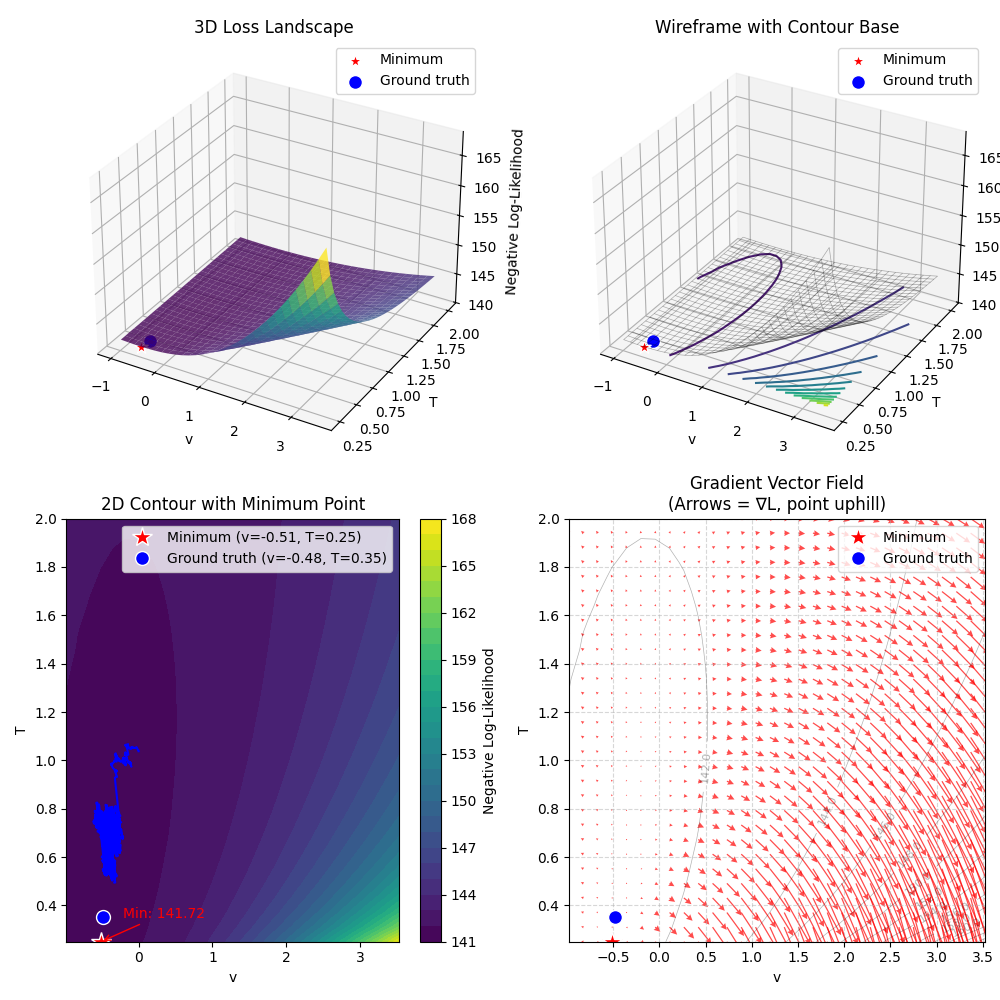

In [67]:
# Find the minimum point
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_v = V0[min_idx]
min_T = T0[min_idx]
min_loss = Z[min_idx]

# === Analysis ===
gt_loss = trunc_nll(phi_std_norm, true_v_std.clone().detach(), true_T_std.clone().detach().flatten(), data)[0]
print(f"Ground truth: v={true_v_std[0].item():.3f}, T={true_T_std[0,0].item():.3f}, loss={gt_loss:.3f}")
print(f"Minimum found: v={min_v:.3f}, T={min_T:.3f}, loss={min_loss:.3f}")
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

param_history = truncated.trainer.param_history 

T_history = param_history[:,0]
v_history = param_history[:,dims**2]

# === Create 3D visualization ===
fig = plt.figure(figsize=(10, 10))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(221, projection='3d')
surf = ax1.plot_surface(V0, T0, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax1.scatter([min_v], [min_T], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax1.scatter([true_v_std[0].item()], [true_T_std[0, 0].item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax1.set_xlabel('v')
ax1.set_ylabel('T')
ax1.set_zlabel('Negative Log-Likelihood')
ax1.set_title('3D Loss Landscape')
ax1.legend()

# Plot 2: 3D wireframe plot
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot_wireframe(V0, T0, Z, color='black', alpha=0.3, linewidth=0.5)
contour = ax2.contour(V0, T0, Z, levels=15, offset=np.min(Z) - 0.1, cmap='viridis')
ax2.scatter([min_v], [min_T], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_v_std[0].item()], [true_T_std[0, 0].item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax2.set_xlabel('v')
ax2.set_ylabel('T')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('Wireframe with Contour Base')
ax2.legend()

# Plot 3: Heatmap with minimum point
ax3 = fig.add_subplot(223)
contourf = ax3.contourf(V0, T0, Z, levels=30, cmap='viridis')
plt.colorbar(contourf, ax=ax3, label='Negative Log-Likelihood')

# Mark minimum and ground truth
ax3.plot(min_v, min_T, 'r*', markersize=15, markeredgecolor='white', 
        label=f'Minimum (v={min_v.item():.2f}, T={min_T.item():.2f})')
ax3.plot(true_v_std[0].item(), true_T_std[0, 0].item(), 'bo', markersize=10, 
        markeredgecolor='white', label=f'Ground truth (v={true_v_std[0].item():.2f}, T={true_T_std[0,0].item():.2f})')

# Add text annotation for the minimum point
ax3.annotate(f'Min: {min_loss:.2f}', 
            xy=(min_v, min_T), 
            xytext=(min_v+0.3, min_T+0.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax3.plot(v_history.detach(), T_history.detach(), color='blue')


ax3.set_xlabel('v')
ax3.set_ylabel('T')
ax3.set_title('2D Contour with Minimum Point')
ax3.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(224)

# Plot quiver
Q = ax4.quiver(V0, T0, GRAD_V0, GRAD_T0,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(V0, T0, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(min_v, min_T, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax4.plot(true_v_std[0].item(), true_T_std[0,0].item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax4.set_xlabel('v')
ax4.set_ylabel('T')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [66]:
truncated.trainer.truncated.trainer.train_losses.argmin()

tensor(55)

In [56]:
truncated.trainer.param_history[truncated.trainer._best_param_index][:dims**2]

tensor([ 0.8878,  0.0363,  0.0266,  ..., -0.0162,  0.0270,  1.0576])

In [63]:
loss, T_grad, v_grad = trunc_nll(phi_std_norm, truncated.trainer.param_history[truncated.trainer._best_param_index][dims**2:], truncated.trainer.param_history[truncated.trainer._best_param_index][:dims**2], truncated.val_loader_.dataset.data, known_cov=False)
loss

142.79910278320312

In [60]:
truncated.val_loader_.dataset.data

tensor([[-0.0810,  1.0809,  0.1940,  ..., -0.2130,  0.5981,  1.2556],
        [ 1.3236, -0.3840, -0.4136,  ..., -1.4654,  0.4827, -0.8018],
        [ 0.9234,  0.3312, -0.7797,  ..., -0.2486, -0.5186, -0.0662],
        ...,
        [-0.4384, -0.2909, -0.7502,  ..., -0.1037, -0.7030,  0.1571],
        [-0.0219, -0.0080, -1.8349,  ...,  1.2586, -0.2063,  0.0886],
        [-0.5066, -0.4887,  1.4811,  ...,  0.4969,  0.4460,  0.1066]])

In [205]:
param_history = truncated.trainer.train_param_history 

T_history = param_history[:,0]
v_history = param_history[:,0]

In [206]:
v_history

tensor([ 0.0160,  0.0115,  0.0045,  ..., -0.0383, -0.0352, -0.0350])

In [212]:
param_history[:,dims**2]

tensor([-0.0074, -0.0150, -0.0294,  ..., -0.6092, -0.5925, -0.5967])

In [209]:
truncated.trainer.val_param_history[truncated.trainer._best_index]

tensor([ 0.4125, -0.0511, -0.0511,  0.9594, -0.6085,  0.0201])

In [80]:
(truncated.ema_covariance_matrix_ * emp_var)[0, 0]

tensor(0.8560)